# Analisis de Sentimiento de Clientes

## Analisis de Sentimiento: contexto del caso

**Tipo de modelo:** Clasificacion supervisada (NLP)
**Variable objetivo:** sentimiento (positivo/negativo/neutro) + urgencia

**Lo que aprenderas:**
1. Como convertir texto en numeros para ML (TF-IDF)
2. Pipeline sklearn completo para clasificacion de texto
3. Como evaluar un clasificador multiclase (precision/recall por clase)
4. Cuando un modelo clasico es suficiente y cuando necesitas un LLM

---

## Contexto del caso de negocio

| | |
|---|---|
| **Empresa** | empresa — área de customer success y calidad de servicio |
| **Problema de negocio** | Clasificar automáticamente el sentimiento de los comentarios de clientes para detectar tendencias negativas sin leer cada ticket manualmente |
| **Datos disponibles** | 45 comentarios textuales de clientes etiquetados manualmente como negativo, neutro o positivo, con fecha, área y canal de origen |
| **Técnica aplicada** | Procesamiento de lenguaje natural (NLP) con TF-IDF para vectorizar el texto, Regresión Logística y SVM como clasificadores; evaluación con matriz de confusión y F1 por clase |
| **Salida del modelo** | Etiqueta de sentimiento (negativo / neutro / positivo) para cada nuevo comentario, con las palabras más informativas por clase |
| **Valor operativo** | Permite priorizar la atención a comentarios negativos en tiempo real y detectar patrones de insatisfacción por área o canal antes de que escalen |

In [ ]:
import os, sys
from pathlib import Path

# Configuracion de entorno: ajusta CWD y descarga datos segun el entorno de ejecucion
_BASE_URL = "https://raw.githubusercontent.com/amador2001/ia-datos/main/"
_CSVS = ["feedback_clientes.csv"]

if "google.colab" in sys.modules:
    import urllib.request
    Path("datos").mkdir(exist_ok=True)
    for _csv in _CSVS:
        _dest = Path("datos") / _csv
        if not _dest.exists():
            urllib.request.urlretrieve(_BASE_URL + _csv, str(_dest))
            print(f"Descargado: {_csv}")
elif "__vsc_ipynb_file__" in dir():
    os.chdir(Path(__vsc_ipynb_file__).parent)
elif not Path("datos").exists():
    for _p in [Path("Jupyter_notebooks"), Path("../Jupyter_notebooks")]:
        if (_p / "datos").exists():
            os.chdir(_p)
            break

print(f"Entorno listo. CWD: {os.getcwd()}")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

In [3]:
# Cargar el dataset de feedback de clientes
df = pd.read_csv("datos/feedback_clientes.csv")

print("Primeras filas del dataset:")
display(df.head(10))

print("\nEstadisticas del dataset:")
print(f"  Total de tickets: {len(df)}")
print(f"  Columnas: {list(df.columns)}")

print("\nDistribucion de sentimiento:")
display(df["sentimiento"].value_counts().to_frame("conteo"))

print("\nDistribucion de urgencia:")
display(df["urgencia"].value_counts().to_frame("conteo"))

print("\nEjemplos de texto por clase:")
for sent in ["positivo", "neutro", "negativo"]:
    ejemplo = df[df["sentimiento"]==sent]["texto_feedback"].iloc[0]
    print(f"\n  [{sent}] {ejemplo[:100]}...")

Primeras filas del dataset:


,ticket_id,texto_feedback,sentimiento,urgencia,categoria,nps_score
0,TKT-0001,"El soporte fue excelente, resolvieron mi consu...",positivo,baja,producto,8
1,TKT-0002,"Muy satisfecho con la plataforma, todo funcion...",positivo,baja,onboarding,10
2,TKT-0003,El equipo de atencion al cliente es muy profes...,positivo,baja,soporte_tecnico,10
3,TKT-0004,"Excelente experiencia de incorporacion, guia m...",positivo,baja,soporte_tecnico,9
4,TKT-0005,El sistema es intuitivo y facil de usar para t...,positivo,baja,producto,9
5,TKT-0006,"Gran producto, supera nuestras expectativas de...",positivo,baja,onboarding,9
6,TKT-0007,"El servicio es impecable, siempre atentos a nu...",positivo,baja,soporte_tecnico,9
7,TKT-0008,"Muy contentos con la implementacion, sin probl...",positivo,baja,comercial,7
8,TKT-0009,La documentacion tecnica es clara y muy completa.,positivo,baja,soporte_tecnico,9
9,TKT-0010,"Renovaremos sin duda, estamos muy satisfechos ...",positivo,baja,producto,9



Estadisticas del dataset:
  Total de tickets: 45
  Columnas: ['ticket_id', 'texto_feedback', 'sentimiento', 'urgencia', 'categoria', 'nps_score']

Distribucion de sentimiento:


,conteo
sentimiento,
negativo,18
positivo,15
neutro,12



Distribucion de urgencia:


,conteo
urgencia,
media,19
baja,18
alta,8



Ejemplos de texto por clase:

  [positivo] El soporte fue excelente, resolvieron mi consulta en menos de una hora....

  [neutro] Necesitamos actualizar los datos de facturacion de nuestra cuenta....

  [negativo] Llevamos tres dias con problemas de acceso al sistema, necesitamos solucion urgente....


### Variables del dataset

| Variable | Tipo | Descripcion |
|---|---|---|
| ticket_id | str | Identificador unico del ticket |
| texto_feedback | str | Texto libre del cliente |
| sentimiento | str | **Target 1**: positivo / neutro / negativo |
| urgencia | str | **Target 2**: baja / media / alta |
| categoria | str | Tipo de incidencia (soporte_tecnico, facturacion...) |
| nps_score | int | Net Promoter Score asociado al ticket [0-10] |

> **TF-IDF (Term Frequency - Inverse Document Frequency)**:
> Convierte cada texto en un vector numerico donde cada dimension es una palabra.
> Las palabras frecuentes en todos los textos (como "el", "que") reciben menos peso.
> Las palabras especificas de una clase (como "excelente", "urgente") reciben mas peso.

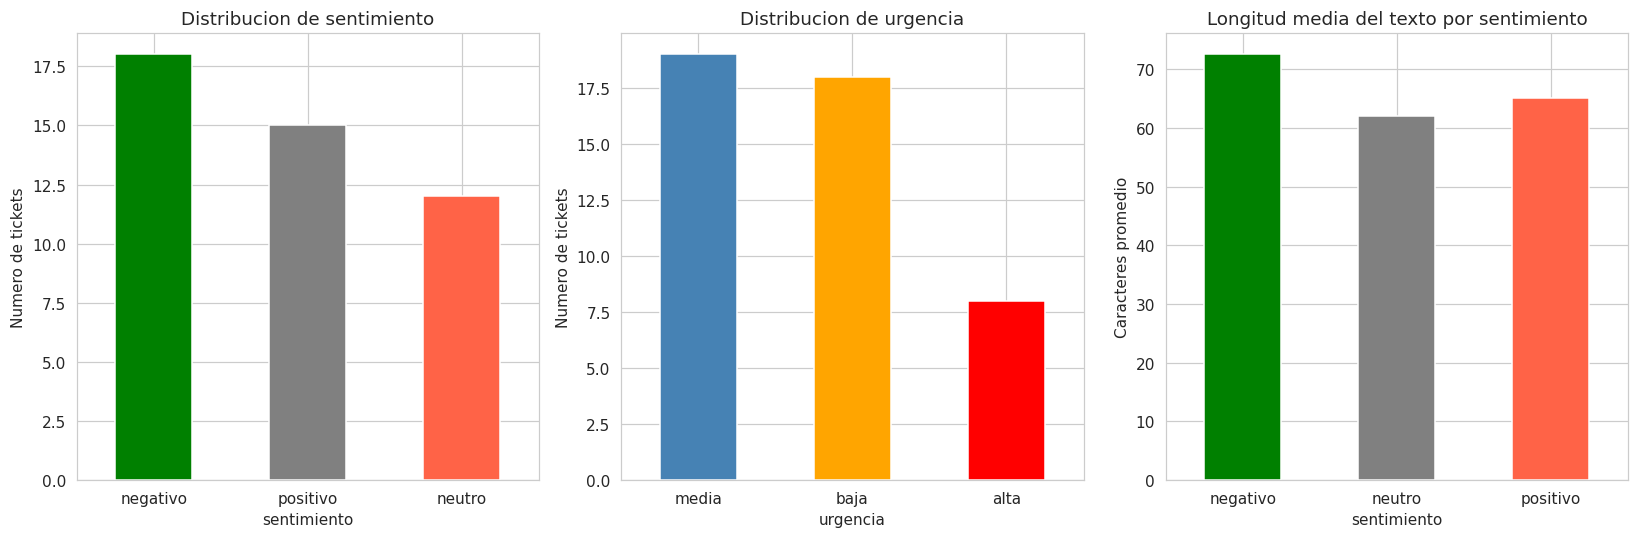

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribucion de clases de sentimiento
df["sentimiento"].value_counts().plot(
    kind="bar", ax=axes[0], color=["green","gray","tomato"],
    rot=0, title="Distribucion de sentimiento"
)
axes[0].set_ylabel("Numero de tickets")

# Distribucion de urgencia
df["urgencia"].value_counts().plot(
    kind="bar", ax=axes[1], color=["steelblue","orange","red"],
    rot=0, title="Distribucion de urgencia"
)
axes[1].set_ylabel("Numero de tickets")

# Longitud media de texto por sentimiento
df["longitud"] = df["texto_feedback"].str.len()
df.groupby("sentimiento")["longitud"].mean().plot(
    kind="bar", ax=axes[2], color=["green","gray","tomato"],
    rot=0, title="Longitud media del texto por sentimiento"
)
axes[2].set_ylabel("Caracteres promedio")

plt.tight_layout()
plt.show()

In [5]:
# Preparar datos: texto como entrada, sentimiento como target
X = df["texto_feedback"]   # texto crudo (strings)
y = df["sentimiento"]      # etiqueta de sentimiento

# Split: 70% entrenamiento, 30% test
# Con 45 muestras, stratify asegura que cada clase este representada en test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y    # garantiza proporcion de clases en train y test
)

print(f"Textos de entrenamiento: {len(X_train)}")
print(f"Textos de test:          {len(X_test)}")
print(f"\nDistribucion en train:\n{y_train.value_counts()}")
print(f"\nDistribucion en test:\n{y_test.value_counts()}")

# TF-IDF es la "normalizacion" para texto: transforma strings en vectores numericos
# ngram_range=(1,2): considera palabras individuales y pares de palabras (bigramas)
# min_df=1: incluir terminos que aparecen al menos 1 vez
# sublinear_tf=True: suaviza la frecuencia de terminos para evitar que palabras muy
#                    frecuentes dominen el vector
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1,
                              max_features=500, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)   # aprende el vocabulario en train
X_test_tfidf  = vectorizer.transform(X_test)        # aplica el mismo vocabulario a test

print(f"\nDimensiones del dataset normalizado (TF-IDF):")
print(f"  Train: {X_train_tfidf.shape} (textos x terminos)")
print(f"  Test:  {X_test_tfidf.shape}")

Textos de entrenamiento: 31
Textos de test:          14

Distribucion en train:
sentimiento
negativo    13
positivo    10
neutro       8
Name: count, dtype: int64

Distribucion en test:
sentimiento
negativo    5
positivo    5
neutro      4
Name: count, dtype: int64

Dimensiones del dataset normalizado (TF-IDF):
  Train: (31, 408) (textos x terminos)
  Test:  (14, 408)


In [6]:
# -- Pipeline 1: TF-IDF + Regresion Logistica ---------------------------------
pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=1,
                              max_features=500, sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=500, random_state=42))
])
pipe_lr.fit(X_train, y_train)    # aprende TF-IDF + pesos del clasificador

# -- Pipeline 2: TF-IDF + SVM lineal ------------------------------------------
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=1,
                              max_features=500, sublinear_tf=True)),
    ("clf",   LinearSVC(max_iter=2000, random_state=42))
])
pipe_svm.fit(X_train, y_train)

# -- Predicciones sobre el conjunto de test ------------------------------------
y_pred_lr  = pipe_lr.predict(X_test)    # predict() devuelve la clase predicha
y_pred_svm = pipe_svm.predict(X_test)

print("Resultados Regresion Logistica:")
print(classification_report(y_test, y_pred_lr))

print("\nResultados SVM lineal:")
print(classification_report(y_test, y_pred_svm))

# Mostrar tabla de predicciones para los primeros tickets del test
tabla = pd.DataFrame({
    "texto": X_test.values[:8],
    "real":  y_test.values[:8],
    "pred_lr":  y_pred_lr[:8],
    "pred_svm": y_pred_svm[:8]
})
print("\nPrimeras 8 predicciones:")
display(tabla)

Resultados Regresion Logistica:
              precision    recall  f1-score   support

    negativo       0.40      0.80      0.53         5
      neutro       0.00      0.00      0.00         4
    positivo       0.75      0.60      0.67         5

    accuracy                           0.50        14
   macro avg       0.38      0.47      0.40        14
weighted avg       0.41      0.50      0.43        14


Resultados SVM lineal:
              precision    recall  f1-score   support

    negativo       0.50      0.60      0.55         5
      neutro       0.67      0.50      0.57         4
    positivo       0.80      0.80      0.80         5

    accuracy                           0.64        14
   macro avg       0.66      0.63      0.64        14
weighted avg       0.65      0.64      0.64        14


Primeras 8 predicciones:


/home/amador/anaconda3/envs/ai-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/amador/anaconda3/envs/ai-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/amador/anaconda3/envs/ai-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r

,texto,real,pred_lr,pred_svm
0,La integracion con nuestro ERP ha fallado y es...,negativo,negativo,neutro
1,URGENTE: el sistema esta completamente caido y...,negativo,negativo,negativo
2,"El soporte fue excelente, resolvieron mi consu...",positivo,negativo,negativo
3,"EMERGENCIA: error critico en facturacion, envi...",negativo,negativo,negativo
4,Queremos saber como exportar los informes en f...,neutro,negativo,negativo
5,Consulta sobre el proceso de renovacion del co...,neutro,negativo,negativo
6,Necesitamos informacion sobre el proceso de mi...,neutro,negativo,neutro
7,Consulta sobre la compatibilidad con nuestro s...,neutro,negativo,neutro


AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

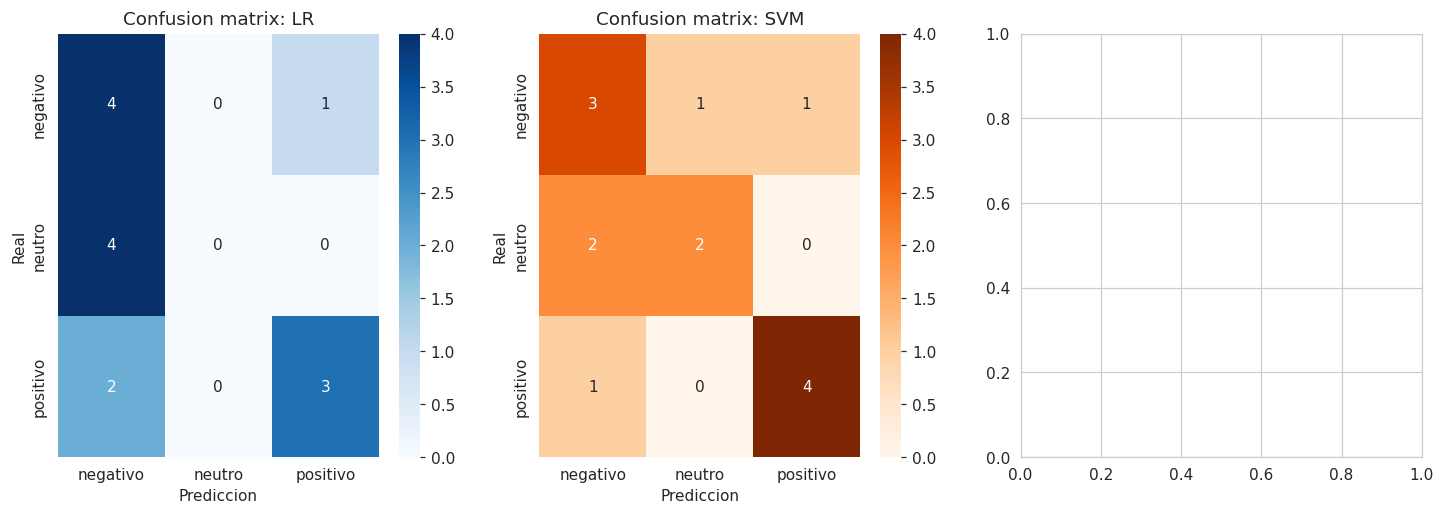

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
clases = ["negativo", "neutro", "positivo"]

# Matriz de confusion LR
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=clases)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=clases, yticklabels=clases, ax=axes[0])
axes[0].set_title("Confusion matrix: LR")
axes[0].set_xlabel("Prediccion"); axes[0].set_ylabel("Real")

# Matriz de confusion SVM
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=clases)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=clases, yticklabels=clases, ax=axes[1])
axes[1].set_title("Confusion matrix: SVM")
axes[1].set_xlabel("Prediccion"); axes[1].set_ylabel("Real")

# Palabras mas informativas por clase (coeficientes del modelo LR)
lr_model = pipe_lr.named_steps["clf"]
vocab = pipe_lr.named_steps["tfidf"].get_feature_names()
top_n = 5
words_per_class = {}
for i, clase in enumerate(lr_model.classes_):
    top_idx = np.argsort(lr_model.coef_[i])[-top_n:]
    words_per_class[clase] = [vocab[j] for j in top_idx]

# Visualizar como barras horizontales apiladas
y_pos = np.arange(top_n)
colors = {"positivo":"green", "neutro":"gray", "negativo":"tomato"}
offset = 0
for clase, words in words_per_class.items():
    axes[2].barh(y_pos + offset*0.25, [1]*top_n, 0.2,
                 label=clase, color=colors[clase], alpha=0.7)
    for j, w in enumerate(words):
        axes[2].text(0.5, j + offset*0.25, w, va="center", fontsize=8)
    offset += 1
axes[2].set_yticks([]); axes[2].set_xticks([])
axes[2].set_title(f"Top {top_n} palabras por clase (LR)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# -- Clasificar un nuevo ticket ------------------------------------------------
nuevos_tickets = [
    "El sistema lleva caido tres horas y no podemos trabajar, es urgente.",
    "Como puedo exportar los informes en formato PDF?",
    "Excelente soporte, resolvieron el problema en menos de una hora."
]

predicciones = pipe_lr.predict(nuevos_tickets)   # predict() sobre lista de textos

for texto, pred in zip(nuevos_tickets, predicciones):
    print(f"Texto:    {texto[:60]}...")
    print(f"Prediccion: {pred.upper()}")
    print()

### Cuando NO usar un modelo clasico de NLP (y usar un LLM en su lugar)

| Situacion | Modelo clasico | LLM |
|---|---|---|
| Clasificar sentimiento en textos cortos en espanol | OK | Excesivo |
| Detectar ironia o contexto cultural | Falla | Necesario |
| Extraer informacion estructurada de contratos | Falla | Necesario |
| Clasificar miles de tickets al dia con latencia baja | Ideal (rapido, barato) | Costoso |
| Pocas muestras de entrenamiento (< 50) | Inestable | Funciona con few-shot |

> La regla: si el problema es clasificar texto con etiquetas claras y suficientes ejemplos,
> un modelo clasico con TF-IDF bate en coste y velocidad a cualquier LLM.
> Si el problema requiere comprension, usa un LLM.